In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\lbrice1\\Documents\\GitHub Repos\\ai_cheme_examples'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [3]:
data = pd.read_excel('data/2.0-zw-Pyrolysis_Data_4-15_Reduced.xlsx')

data.head()

,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,2016-02-08 00:01:00,52285.872450,8547.494766,8978.327424,9357.470901,8957.223865,7775.966322,8560.723802,4393.776603,4402.800896,...,625.470850,624.958202,838.087231,838.164859,838.051705,839.634989,839.173723,835.603783,1015.874004,838.172544
1,2016-02-08 00:16:00,52366.836130,8579.277205,8972.173145,9362.073269,8980.865142,7794.664685,8544.727866,4411.197294,4378.762040,...,625.408625,624.906378,837.440458,840.343755,838.190985,836.150868,838.873225,841.042800,1013.053608,838.678272
2,2016-02-08 00:31:00,52275.680685,8551.972418,9003.021754,9321.712653,8943.094273,7806.982089,8557.347951,4405.819682,4406.877718,...,625.305447,624.575994,837.271119,836.131138,837.985024,840.251943,839.809701,840.314453,1015.694290,838.619070
3,2016-02-08 00:41:00,52384.019953,8547.920127,8991.534062,9326.887823,8963.589735,7811.920025,8598.247872,4402.730208,4391.711508,...,625.236662,624.355739,837.904604,839.058344,837.068393,838.029430,839.609082,837.038558,1016.267551,838.136643
4,2016-02-08 00:56:00,52313.273068,8530.787725,8990.634637,9335.973327,8958.809428,7772.523976,8576.032560,4406.699135,4401.453115,...,625.133484,624.025355,837.803211,837.767467,838.069275,840.034307,837.580220,838.166467,1013.241861,838.199481


In [4]:
def plot_data(data):

    fig = plt.figure(figsize=(10, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for col in data.iloc[:, 1:].columns:

        axs0.plot(np.asarray(data.iloc[:, 0]), np.asarray(data[col]))


    axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', rotation=45)

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)


    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

In [5]:
def plot_clusters(data, basis_data = None, dr_model = None):
    scaler = MinMaxScaler(feature_range=(-1, 1))

    try:
        
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 0:]))
    
    except:
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 1:]))

    scaled_data.head()

    # Project data in 2D
    if dr_model is None:
        dr_model = pacmap.PaCMAP(
            n_neighbors=10,
            MN_ratio=5,
            FP_ratio=20,
            # distance=euclidean,
            lr=1.0,
            apply_pca=True,
            verbose=False,
            intermediate=False,
            save_tree=True
            )

        reduced_data = dr_model.fit_transform(scaled_data.values, )
    
    else:
        reduced_data = dr_model.transform(scaled_data.values, basis = basis_data.iloc[:, 1:].values)


    # get clusters

        
    cl_model = hdbscan.HDBSCAN(
        min_samples=int(np.floor(scaled_data.shape[0] / 50)))
    labels = cl_model.fit_predict(reduced_data)

    clustered_df = pd.DataFrame(
        data={
            'd0': reduced_data[:, 0],
            'd1': reduced_data[:, 1],
            # 'd2': reduced_data[:, 2],
            'label': labels
        })

    #clustered_df = clustered_df.loc[clustered_df.label != -1]

    clustered_df['target'] = data.iloc[:, -1]

    fig1 = plt.figure(figsize=(5, 5))

    clustered_df_denoised = clustered_df.loc[clustered_df.label != -1]

    axs1 = fig1.add_subplot(111)  #projection='3d')
    print('Preparing plot...')

    colors = clustered_df_denoised['label']
    cmap='Set3'

    axs1.scatter(
        clustered_df_denoised['d0'],
        clustered_df_denoised['d1'],
        #this_cluster['d2'],
        s=10,
        cmap=cmap,
        c=colors,#clustered_df_denoised['label'],  #data.iloc[:, 1]
        # marker='o',
        edgecolors='k',
        # alpha=0.9,
        linewidths=0.1,
        # label=label
        )

    noise_df = clustered_df.loc[clustered_df.label == -1]

    axs1.scatter(
                noise_df['d0'],
                noise_df['d1'],
                #this_cluster['d2'],
                s=7,
                cmap=cmap,
                c='k',  #data.iloc[:, 1]
                # marker='o',
                edgecolors='k',
                alpha=0.4,
                linewidths=0.1,
    )

    axs1.set_xlabel(r'$ \rm PaCAMP\ 0$', labelpad = 10, fontsize='x-large')
    axs1.set_ylabel(r'$ \rm PaCAMP\ 1$', labelpad = 10, fontsize='x-large')

    axs1.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large')

    axs1.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs1.spines[ax].set_linewidth(1)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return dr_model, clustered_df.label
 

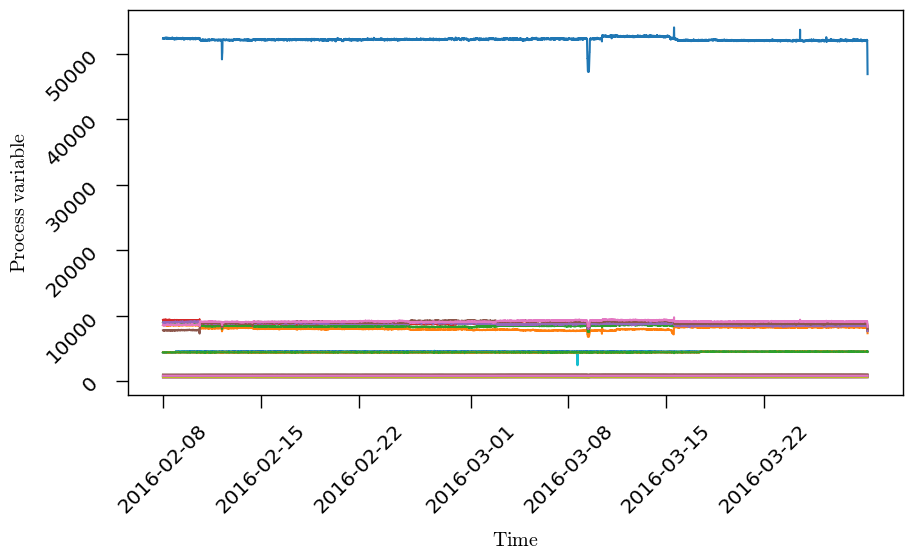

In [6]:
plot_data(data)

Preparing plot...


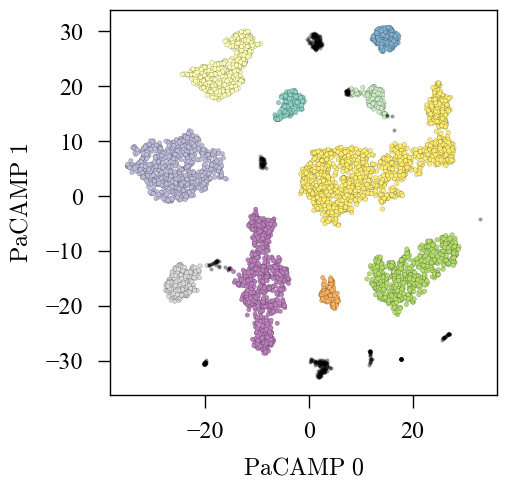

In [7]:
dr_model, labels = plot_clusters(data)

In [8]:
data = pd.read_excel('data/2.0-zw-Pyrolysis_Data_4-15_Reduced.xlsx')

data.head()

,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,2016-02-08 00:01:00,52285.872450,8547.494766,8978.327424,9357.470901,8957.223865,7775.966322,8560.723802,4393.776603,4402.800896,...,625.470850,624.958202,838.087231,838.164859,838.051705,839.634989,839.173723,835.603783,1015.874004,838.172544
1,2016-02-08 00:16:00,52366.836130,8579.277205,8972.173145,9362.073269,8980.865142,7794.664685,8544.727866,4411.197294,4378.762040,...,625.408625,624.906378,837.440458,840.343755,838.190985,836.150868,838.873225,841.042800,1013.053608,838.678272
2,2016-02-08 00:31:00,52275.680685,8551.972418,9003.021754,9321.712653,8943.094273,7806.982089,8557.347951,4405.819682,4406.877718,...,625.305447,624.575994,837.271119,836.131138,837.985024,840.251943,839.809701,840.314453,1015.694290,838.619070
3,2016-02-08 00:41:00,52384.019953,8547.920127,8991.534062,9326.887823,8963.589735,7811.920025,8598.247872,4402.730208,4391.711508,...,625.236662,624.355739,837.904604,839.058344,837.068393,838.029430,839.609082,837.038558,1016.267551,838.136643
4,2016-02-08 00:56:00,52313.273068,8530.787725,8990.634637,9335.973327,8958.809428,7772.523976,8576.032560,4406.699135,4401.453115,...,625.133484,624.025355,837.803211,837.767467,838.069275,840.034307,837.580220,838.166467,1013.241861,838.199481


In [9]:
labels

0      -1
1      -1
2      -1
3      -1
4      -1
       ..
5810    2
5811    2
5812    2
5813    2
5814    2
Name: label, Length: 5815, dtype: int64

In [10]:
from imblearn.under_sampling import CondensedNearestNeighbour  
cnn = CondensedNearestNeighbour(random_state=42, n_neighbors=5)

filtered_data = cnn.fit_resample(data.iloc[:, 1:], labels) 


filtered_data[0].head()

,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,11FC05043PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,52365.182854,8364.808753,8336.884737,8715.180437,9045.574389,8783.296576,9137.969007,4415.893153,4502.657001,4529.294479,...,610.869028,616.440910,825.114284,829.500935,832.572192,836.218422,852.118269,851.352835,1029.521371,837.775359
1,52285.872450,8547.494766,8978.327424,9357.470901,8957.223865,7775.966322,8560.723802,4393.776603,4402.800896,4394.992441,...,625.470850,624.958202,838.087231,838.164859,838.051705,839.634989,839.173723,835.603783,1015.874004,838.172544
2,52366.836130,8579.277205,8972.173145,9362.073269,8980.865142,7794.664685,8544.727866,4411.197294,4378.762040,4414.984887,...,625.408625,624.906378,837.440458,840.343755,838.190985,836.150868,838.873225,841.042800,1013.053608,838.678272
3,52365.182854,8364.808753,8336.884737,8715.180437,9045.574389,8783.296576,9137.969007,4415.893153,4502.657001,4529.294479,...,610.869028,616.440910,825.114284,829.500935,832.572192,836.218422,852.118269,851.352835,1029.521371,837.775359
4,52043.104250,8083.947779,8398.438393,8736.103887,8807.883639,8872.902930,9049.428439,4411.728225,4518.057318,4500.524053,...,605.988088,613.752312,836.619542,836.901352,836.774212,840.036467,842.239827,839.078768,1025.265275,838.578234


In [11]:
# plot_data(filtered_data[0].dropna())

Preparing plot...


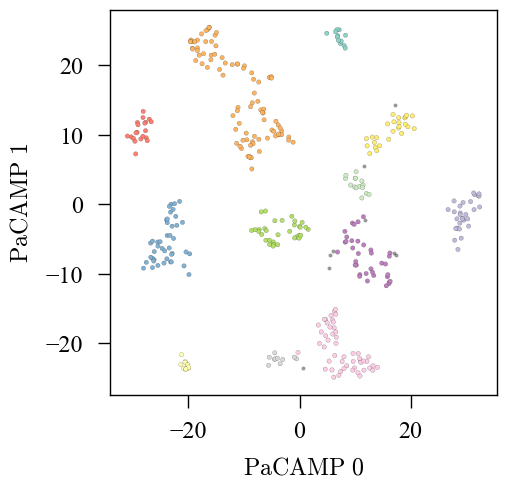

In [16]:
dr_model, labels = plot_clusters(data = filtered_data[0].dropna())#, basis_data=data, dr_model=dr_model)

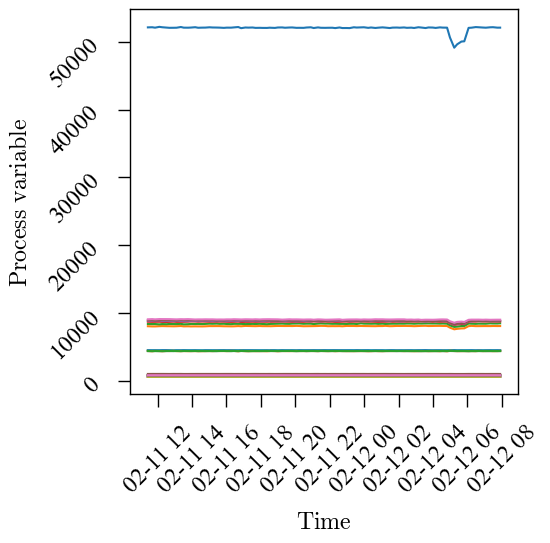

In [13]:
fig = plt.figure(figsize=(5, 5))
axs0 = fig.add_subplot(1, 1, 1)

lb = 400
up = 500

for col in data.iloc[:, 1:].columns:

    axs0.plot(np.asarray(data.iloc[lb:up, 0]), np.asarray(data[col])[lb:up])


axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large', rotation=45)

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=12
plt.rcParams['axes.linewidth'] = 1 

plt.show()

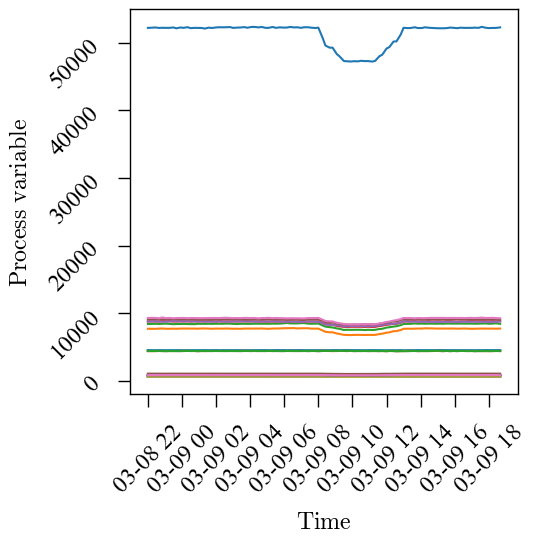

In [14]:
fig = plt.figure(figsize=(5, 5))
axs0 = fig.add_subplot(1, 1, 1)

lb = 3450
up = 3550

for col in data.iloc[:, 1:].columns:

    axs0.plot(np.asarray(data.iloc[lb:up, 0]), np.asarray(data[col])[lb:up])


axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large', rotation=45)

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=12
plt.rcParams['axes.linewidth'] = 1 

plt.show()

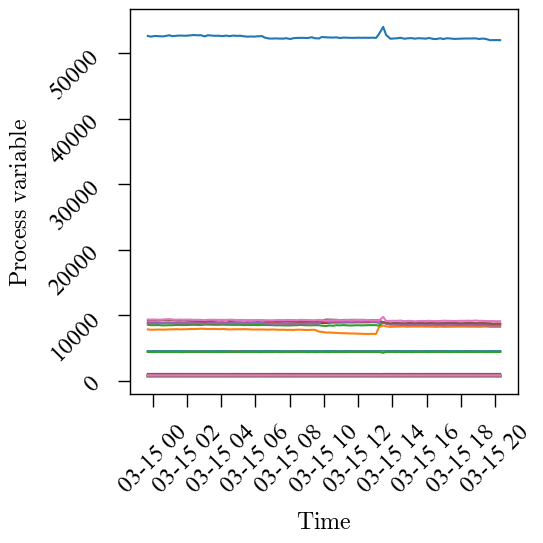

In [15]:
fig = plt.figure(figsize=(5, 5))
axs0 = fig.add_subplot(1, 1, 1)

lb = 4150
up = 4250

for col in data.iloc[:, 1:].columns:

    axs0.plot(np.asarray(data.iloc[lb:up, 0]), np.asarray(data[col])[lb:up])


axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large', rotation=45)

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=12
plt.rcParams['axes.linewidth'] = 1 

plt.show()